In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from gaussian_beam import GaussianBeam
from fit_gaussian_beam_data import *

**Please update these paramters to reflect your set up and what you wish to test**

In [ ]:
# parameters of physical set up
delta = -0.026908155250368385 - 2.8722247547626617e-06 # because we cannot measure where the collimator lens is, we must adjust for this fact be iterating until the beam waist loc of the reconstructed beam is zero
d_col = 3.5*10**-2 + delta # distance from fiberoptic pen beam to end of collimator
d_lens_col = 29.6*10**-2 - delta # distance from end of collimator to lens
d_lens = 0 # distance from lens to measurement mount
f_col = 8*10**-3
f_lens = 200*10**-3
d_err = 0.000

laser_wavelength = 397*10**-9 # update me
filepath = os.path.expanduser("~/Desktop/REU/Data/397--data_20cm.csv")

In [ ]:
# lenses you want to test for the waist size/waist location vs fiber-collimator separation graph
d_optimal = 26 # optimal fiber-collimator separation
d_arr = np.linspace(d_optimal-10, d_optimal+10, 100)*10**-3 # spacings to test for fiber-collimator separation
f_lens1_arr = np.array([20, 25, 26])*10**-3 # focal lengths to plot
d_lens2 = 25*10**-2 # collimator to second lens length
f_lens2 = 200*10**-3 # second lens focal length

# plotting parameters for the waist size/waist location vs fiber-collimator and collimator-lens separation graph
d1_optimal = 25 # optimal spacing for fiber-collimator separation
f_lens1 = 26*10**-3 # collimating lens focal length
d2_optimal = 25 # optimal spacing for collimator-lens separation
d1, d2 = np.meshgrid(np.linspace(d1_optimal-10, d1_optimal+10, 100)*10**-3, np.linspace(d2_optimal-10, d2_optimal+10, 100)*10**-2) # spacings to plot
f_lens2 = 200*10**-3 # second lens focal length

**Create the beam object using your experimental data**

Beam Radius List: [np.float64(6.446148126661051e-05), np.float64(4.82142421626008e-05), np.float64(3.77954158092432e-05), np.float64(3.698549511572392e-05), np.float64(3.051848547285059e-05), np.float64(3.103982766657078e-05), np.float64(2.985349870316432e-05), np.float64(3.2679859116537686e-05), np.float64(3.3899507580915804e-05), np.float64(4.330663476124651e-05), np.float64(6.021300464052956e-05)]
Fitted Beam Parameters:
Beam Waist: 3.140128669579745e-05 ± 7.245593604839398e-07 m
Beam Waist Location: 0.006274050651983021 ± 0.00010950243746081628 m
M^2: 1.2291661251418495 ± 0.03155876689317324
Rayleigh Range: 0.00345705786984063 ± 0.00018744597029064162 m
Divergence Angle: 0.0027140670456397937 ± 0.01796521807846916 degrees


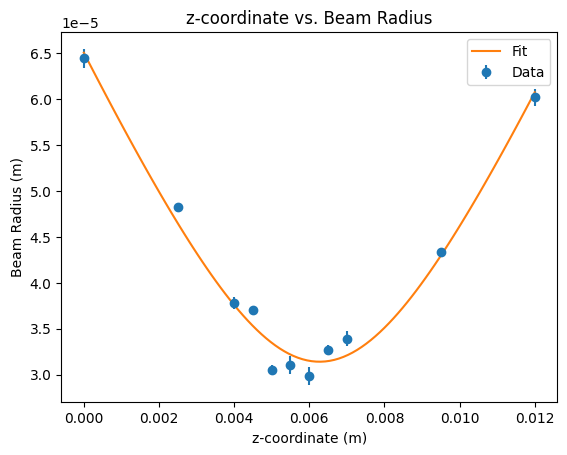

PTE 1.1102230246251565e-16
Reduced Chi Squared 11.777206819202563

 
Original Beam Parameters:
Beam waist 1.4251771056848018e-06 ± 2.5518850342192864e-08
Beam waist loc 3.205174245327416e-07 ± 4.1031550133254865e-07
Rayleigh Range 7.1211385529766124e-06 ± 1.777804046146117e-07
M^2 1.2291661251418495 ± 0.03155876689317324


In [132]:
# create initial beam
# fit experimental data to determine beam parameters
beam_params = process_data(filepath, laser_wavelength)

# set beam using fitted beam parameters
myBeam = GaussianBeam(*beam_params, laser_wavelength)

# reconstruct original beam (use negatives because it is backwards but with my sign convention those become positive)
myBeam.free_space(d_lens, d_err)
myBeam.lens(f_lens)
myBeam.free_space(d_lens_col, d_err)
myBeam.lens(f_col)
myBeam.free_space(d_col, d_err)
print("\n \nOriginal Beam Parameters:")
myBeam.print()

**Plotting Waist Size/Waist Location vs Fiber-Collimator Separation**

There are two different graph options depending on what displays nicer for your lenses.

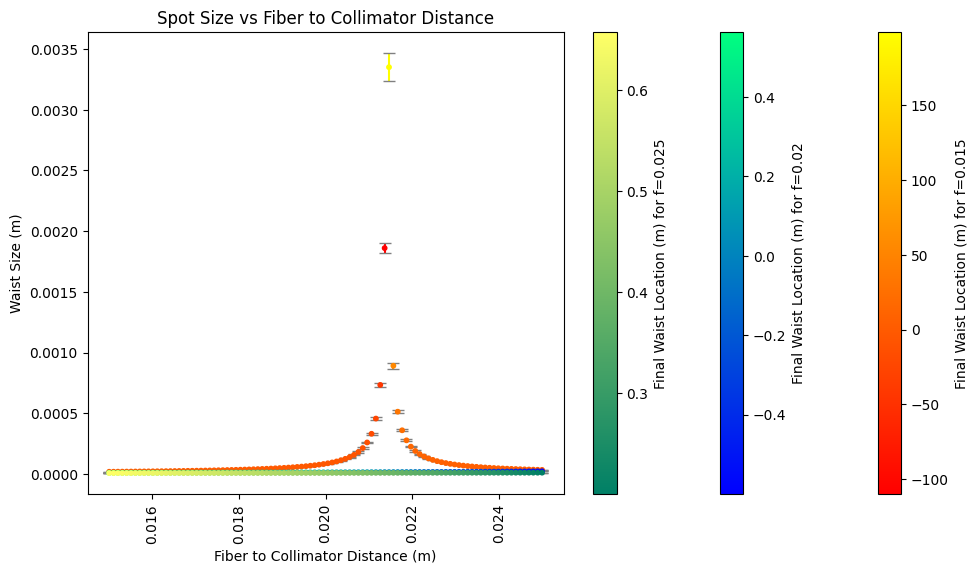

In [136]:
fig, ax = plt.subplots(figsize=(12,6))

maps = ['autumn', 'winter', 'summer']
counter = 0
for f_lens1 in f_lens1_arr:
    spot_arr = []
    spot_err_arr = []
    waist_loc_arr = []
    waist_loc_err_arr = []

    for d_lens1 in d_arr:
        temp_params = myBeam.get_beam_params()
        temp_beam = GaussianBeam(*temp_params, laser_wavelength)
        # pass the beam back through to ensure you get the fitted beam back (with my sign convention these distances have to be negative)
        temp_beam.free_space(-d_lens1, d_err)
        temp_beam.lens(-f_lens1)
        temp_beam.free_space(-d_lens2, d_err)
        temp_beam.lens(-f_lens2)
        spot_arr.append(temp_beam.get_waist())
        spot_err_arr.append(temp_beam.get_waist_err())
        waist_loc_arr.append(temp_beam.get_waist_loc())
        waist_loc_err_arr.append(temp_beam.get_waist_loc_err())
        
    scatter = ax.scatter(d_arr, spot_arr, c=waist_loc_arr, cmap=maps[counter], s=10, zorder=3, label=f"F={f_lens1}")
    
    cbar = plt.colorbar(scatter)
    cbar.set_label(f"Final Waist Location (m) for f={f_lens1}")
    
    errorbar = ax.errorbar(d_arr, spot_arr, yerr=spot_err_arr, fmt='none', ecolor='gray', elinewidth=1.5, capsize=4, zorder=2)
    
    colors = scatter.to_rgba(waist_loc_arr)
    errorbar[2][0].set_color(colors)
    counter += 1

plt.xticks(rotation=90)
ax.set_xlabel("Fiber to Collimator Distance (m)")
ax.set_ylabel("Waist Size (m)")
ax.set_title("Spot Size vs Fiber to Collimator Distance");

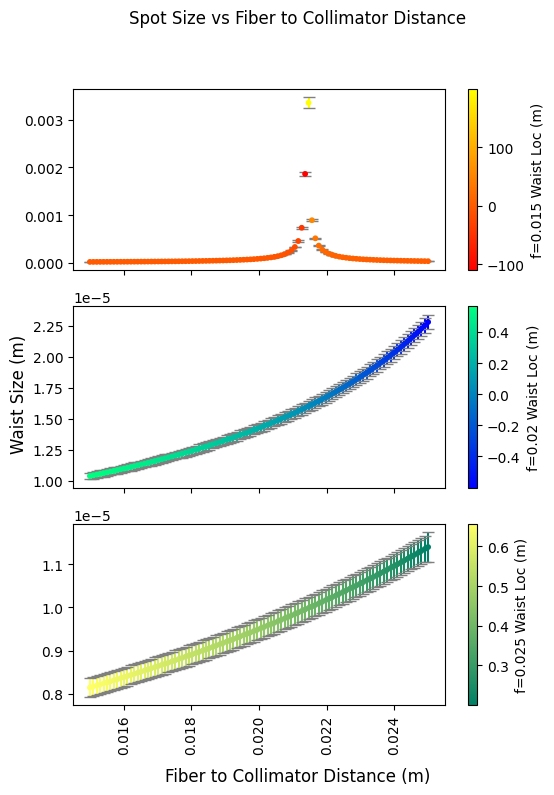

In [137]:
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(6, 8))

maps = ['autumn', 'winter', 'summer']
counter = 0
for f_lens1 in f_lens1_arr:
    spot_arr = []
    spot_err_arr = []
    waist_loc_arr = []
    waist_loc_err_arr = []

    for d_lens1 in d_arr:
        temp_params = myBeam.get_beam_params()
        temp_beam = GaussianBeam(*temp_params, laser_wavelength)
        # pass the beam back through to ensure you get the fitted beam back (with my sign convention these distances have to be negative)
        temp_beam.free_space(-d_lens1, d_err)
        temp_beam.lens(-f_lens1)
        temp_beam.free_space(-d_lens2, d_err)
        temp_beam.lens(-f_lens2)
        spot_arr.append(temp_beam.get_waist())
        spot_err_arr.append(temp_beam.get_waist_err())
        waist_loc_arr.append(temp_beam.get_waist_loc())
        waist_loc_err_arr.append(temp_beam.get_waist_loc_err())
        
    scatter = ax[counter].scatter(d_arr, spot_arr, c=waist_loc_arr, cmap=maps[counter], s=10, zorder=3, label=f"F={f_lens1}")
    
    cbar = plt.colorbar(scatter)
    cbar.set_label(f"f={f_lens1} Waist Loc (m)")
    
    errorbar = ax[counter].errorbar(d_arr, spot_arr, yerr=spot_err_arr, fmt='none', ecolor='gray', elinewidth=1.5, capsize=4, zorder=2)
    
    colors = scatter.to_rgba(waist_loc_arr)
    errorbar[2][0].set_color(colors)
    counter += 1

plt.xticks(rotation=90)
fig.supxlabel("Fiber to Collimator Distance (m)")
fig.supylabel("Waist Size (m)")
fig.suptitle("Spot Size vs Fiber to Collimator Distance");

**Waist Size/Waist Location vs Fiber-Collimator and Collimator-Lens Separation**

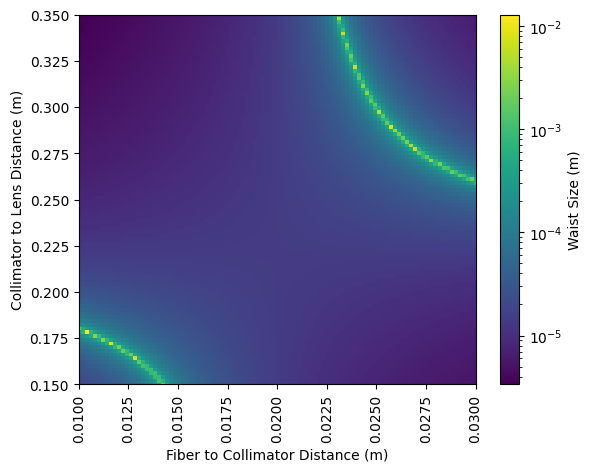

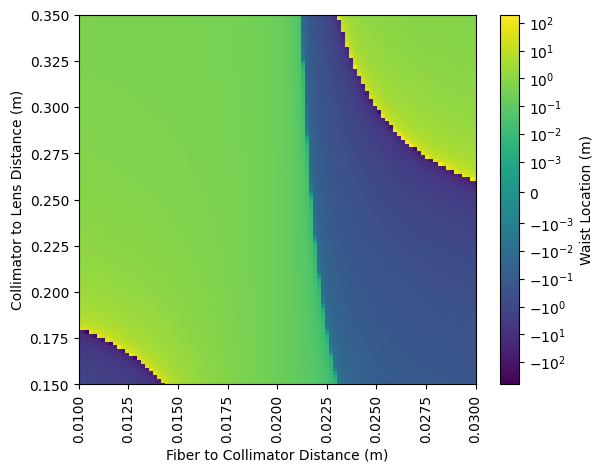

In [141]:
# plot spot size/waist location vs distance to collimator
spot_arr = np.ones(shape = (len(d1), len(d1[0])))
spot_err_arr = np.ones(shape = (len(d1), len(d1[0])))
waist_loc_arr = np.ones(shape = (len(d1), len(d1[0])))
waist_loc_err_arr = np.ones(shape = (len(d1), len(d1[0])))

for i in range(len(d1)):
    for j in range(len(d1[0])):
        d_lens1 = d1[i][j]
        d_lens2 = d2[i][j]
        temp_params = myBeam.get_beam_params()
        temp_beam = GaussianBeam(*temp_params, laser_wavelength)
        # pass the beam back through to ensure you get the fitted beam back (with my sign convention these distances have to be negative)
        temp_beam.free_space(-d_lens1, d_err)
        temp_beam.lens(-f_lens1)
        temp_beam.free_space(-d_lens2, d_err)
        temp_beam.lens(-f_lens2)
        spot_arr[i][j] = temp_beam.get_waist()
        spot_err_arr[i][j] = temp_beam.get_waist_err()
        waist_loc_arr[i][j] = temp_beam.get_waist_loc()
        waist_loc_err_arr[i][j] = temp_beam.get_waist_loc_err()

spot_min, spot_max = spot_arr.min(), spot_arr.max()
loc_min, loc_max = waist_loc_arr.min(), waist_loc_arr.max()

fig1, ax1 = plt.subplots()

c1 = ax1.pcolormesh(d1, d2, spot_arr, cmap='viridis', norm=matplotlib.colors.LogNorm(vmin=spot_min, vmax=spot_max))
ax1.set_xlabel("Fiber to Collimator Distance (m)")
ax1.set_ylabel("Collimator to Lens Distance (m)")
# set the limits of the plot to the limits of the data
ax1.axis([d1.min(), d1.max(), d2.min(), d2.max()])
cbar1 = fig1.colorbar(c1, ax=ax1)
cbar1.set_label("Waist Size (m)")
plt.xticks(rotation=90)

fig2, ax2 = plt.subplots()

#c2 = ax2.pcolormesh(d1, d2, waist_loc_arr, cmap='viridis', vmin=loc_min, vmax=loc_max)
c2 = ax2.pcolormesh(d1, d2, waist_loc_arr, cmap='viridis', norm=matplotlib.colors.SymLogNorm(linthresh = 1*10**-3, vmin=loc_min, vmax=loc_max))
ax2.set_xlabel("Fiber to Collimator Distance (m)")
ax2.set_ylabel("Collimator to Lens Distance (m)")
# set the limits of the plot to the limits of the data
ax2.axis([d1.min(), d1.max(), d2.min(), d2.max()])
cbar2 = fig2.colorbar(c2, ax=ax2)
cbar2.set_label("Waist Location (m)")
plt.xticks(rotation=90)
plt.show();